In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)

df   = pd.read_csv("df_prepared.csv")
X_cr = pd.read_csv("X_cr.csv")

features = list(X_cr.columns)
X = X_cr[features].values
y = df['quality_cat'].values   # mauvais / moyen / bon

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# === ANALYSE DISCRIMINANTE (LDA) ===
print("=== Analyse Discriminante Linéaire (LDA) ===\n")

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)

acc_lda = accuracy_score(y_test, y_pred_lda)
print(f"Accuracy LDA : {acc_lda:.3f} ({acc_lda*100:.1f}%)")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_lda, zero_division=0))



=== Analyse Discriminante Linéaire (LDA) ===

Accuracy LDA : 0.588 (58.8%)

Rapport de classification :
              precision    recall  f1-score   support

         bon       0.64      0.39      0.49        46
     mauvais       0.64      0.74      0.68       160
       moyen       0.50      0.48      0.49       134

    accuracy                           0.59       340
   macro avg       0.59      0.54      0.55       340
weighted avg       0.59      0.59      0.58       340



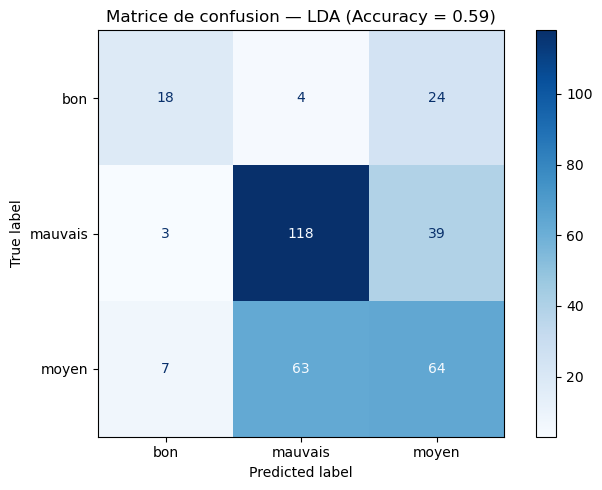

In [2]:
# Matrice de confusion LDA
cm_lda = confusion_matrix(y_test, y_pred_lda, labels=lda.classes_)
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(cm_lda, display_labels=lda.classes_).plot(ax=ax, cmap='Blues')
ax.set_title(f"Matrice de confusion — LDA (Accuracy = {acc_lda:.2f})")
plt.tight_layout()
plt.savefig("lda_confusion.png", dpi=150)
plt.show()


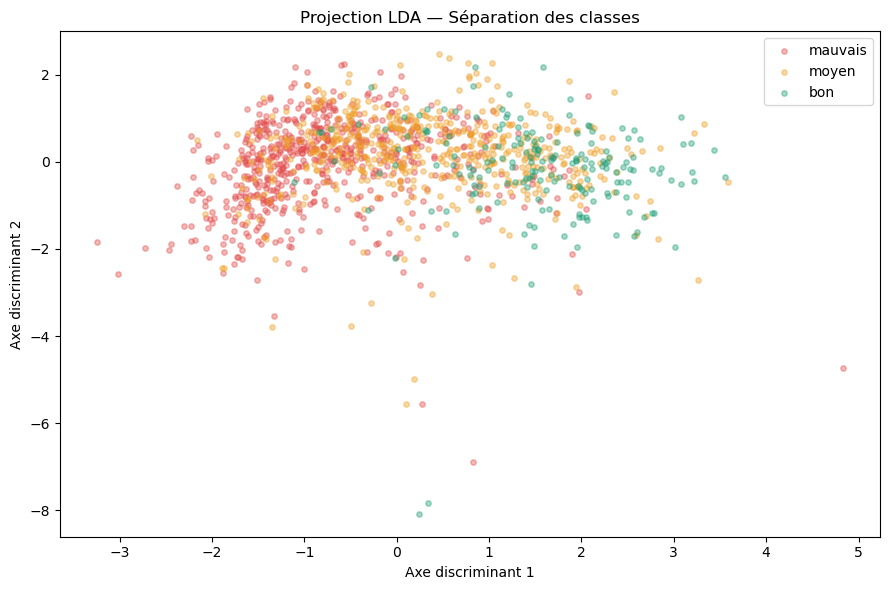



=== Arbre de Décision (CART) ===



In [3]:
# Projection LDA sur les axes discriminants
X_lda = lda.transform(X)
plt.figure(figsize=(9, 6))
colors = {'mauvais': '#E24B4A', 'moyen': '#EF9F27', 'bon': '#1D9E75'}
for cat in ['mauvais', 'moyen', 'bon']:
    mask = df['quality_cat'] == cat
    plt.scatter(X_lda[mask, 0],
                X_lda[mask, 1] if X_lda.shape[1] > 1 else np.zeros(mask.sum()),
                color=colors[cat], alpha=0.4, s=15, label=cat)
plt.xlabel("Axe discriminant 1")
plt.ylabel("Axe discriminant 2" if X_lda.shape[1] > 1 else "")
plt.title("Projection LDA — Séparation des classes")
plt.legend()
plt.tight_layout()
plt.savefig("lda_projection.png", dpi=150)
plt.show()

# === ARBRE DE DÉCISION ===
print("\n\n=== Arbre de Décision (CART) ===\n")



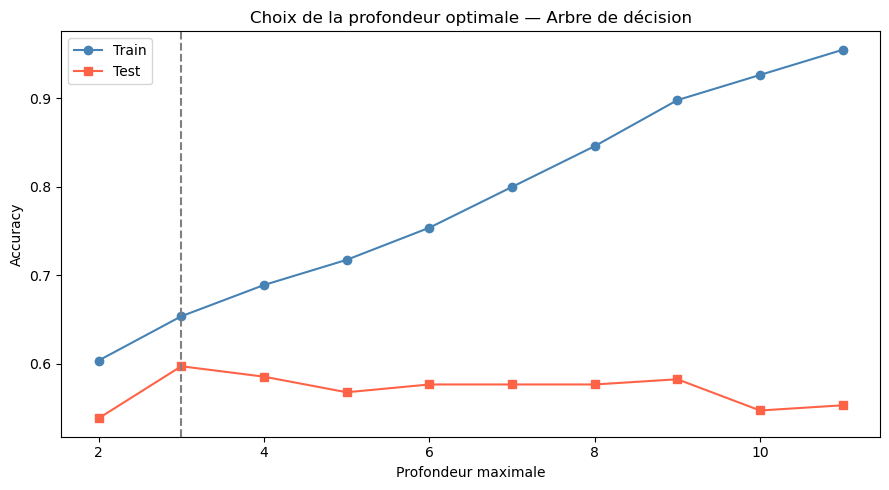

In [5]:
# Choix de la profondeur optimale par cross-validation simple
depths = range(2, 12)
train_acc, test_acc = [], []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, dt.predict(X_train)))
    test_acc.append(accuracy_score(y_test, dt.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_acc, 'o-', label='Train', color='steelblue')
plt.plot(depths, test_acc, 's-', label='Test', color='tomato')
plt.xlabel("Profondeur maximale")
plt.ylabel("Accuracy")
plt.title("Choix de la profondeur optimale — Arbre de décision")
plt.legend()
plt.axvline(x=test_acc.index(max(test_acc)) + 2, color='gray',
            linestyle='--', label=f'Profondeur opt. = {test_acc.index(max(test_acc))+2}')
plt.tight_layout()
plt.savefig("arbre_profondeur.png", dpi=150)
plt.show()



In [6]:
# Modèle final
best_depth = test_acc.index(max(test_acc)) + 2
dt_final = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_final.fit(X_train, y_train)
y_pred_dt = dt_final.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Profondeur optimale : {best_depth}")
print(f"Accuracy Arbre       : {acc_dt:.3f} ({acc_dt*100:.1f}%)")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_dt, zero_division=0))


Profondeur optimale : 3
Accuracy Arbre       : 0.597 (59.7%)

Rapport de classification :
              precision    recall  f1-score   support

         bon       0.75      0.26      0.39        46
     mauvais       0.67      0.69      0.68       160
       moyen       0.51      0.60      0.55       134

    accuracy                           0.60       340
   macro avg       0.64      0.52      0.54       340
weighted avg       0.62      0.60      0.59       340



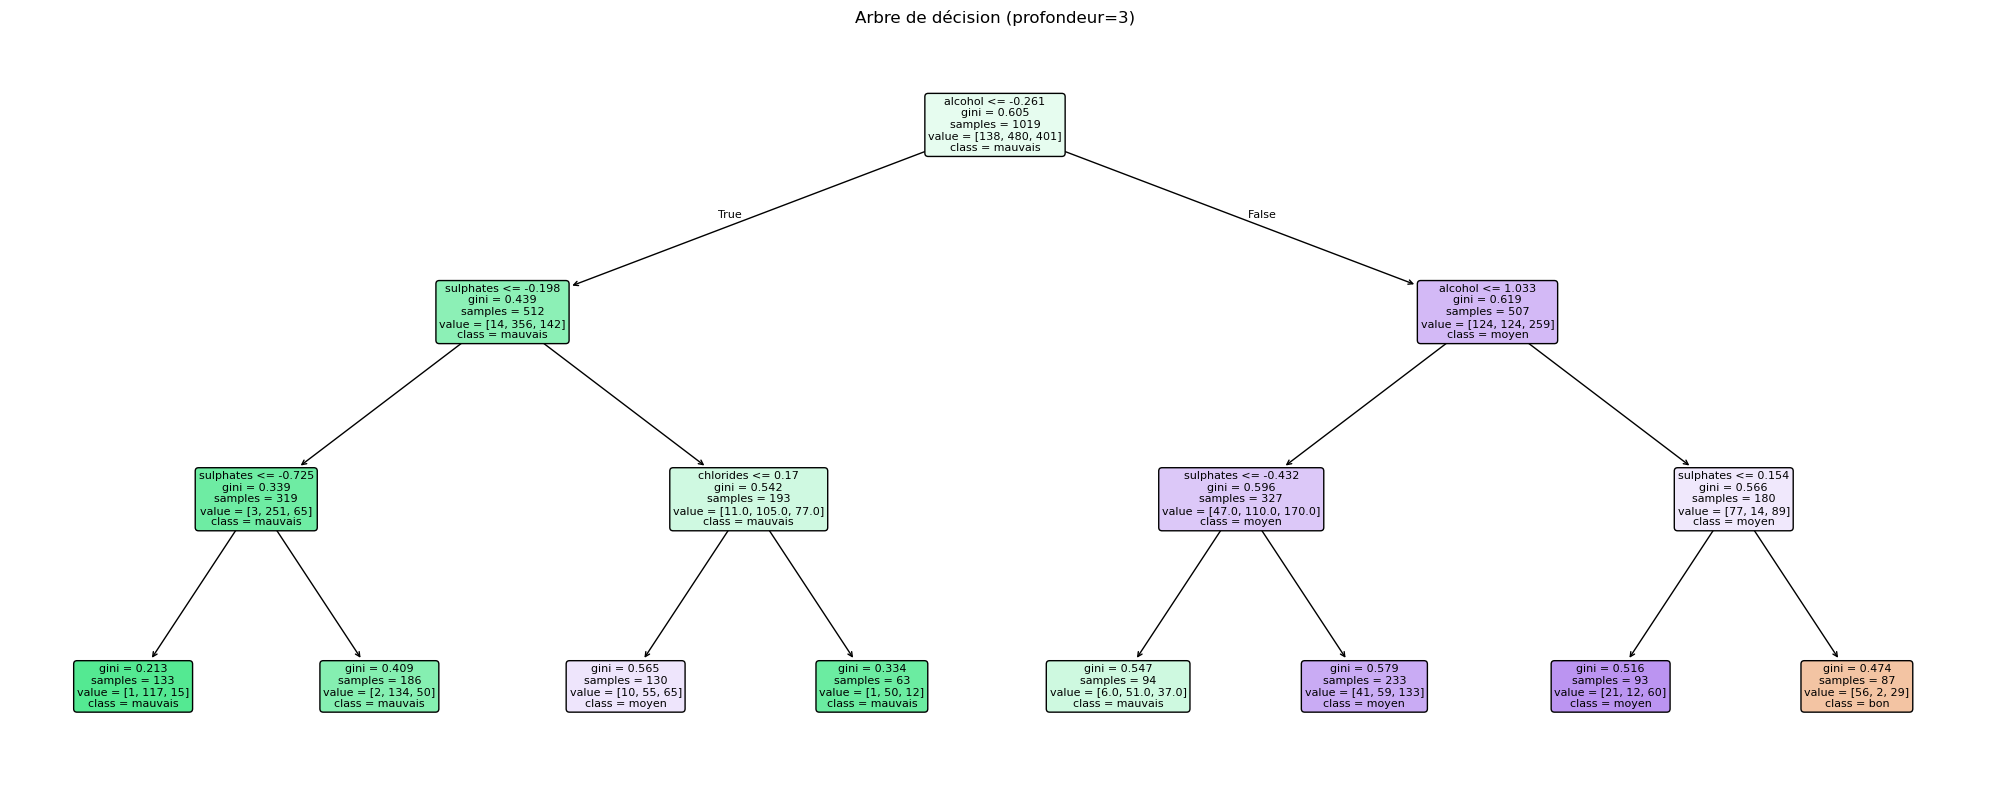

In [7]:
# Visualisation de l'arbre
plt.figure(figsize=(20, 8))
plot_tree(dt_final, feature_names=features,
          class_names=dt_final.classes_,
          filled=True, rounded=True, fontsize=8,
          max_depth=3)
plt.title(f"Arbre de décision (profondeur={best_depth})")
plt.tight_layout()
plt.savefig("arbre_decision.png", dpi=150)
plt.show()


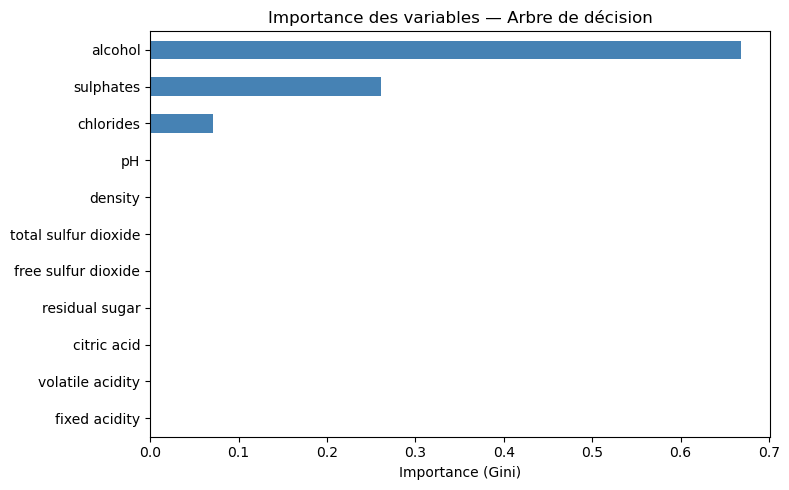

In [8]:
# Importance des variables
importances = pd.Series(dt_final.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title("Importance des variables — Arbre de décision")
plt.xlabel("Importance (Gini)")
plt.tight_layout()
plt.savefig("arbre_importance.png", dpi=150)
plt.show()